Engenharia de Dados e Infraestrutura: Você provou que consegue processar 1,3 milhão de pacientes no Colab gratuito, sabendo contornar o estouro de RAM limpando as features de alta cardinalidade.

Otimização Matemática: Você gerou o gráfico do Learning Rate Finder com seus próprios dados e sabe justificar a escolha da taxa com base no artigo do Leslie Smith.

Estado da Arte Médico: Você conectou o laço de treinamento rodando a função Cox Partial Likelihood, mostrando que o modelo já compreende o conceito de dados censurados e tempo de sobrevivência.

# Aplicação de um modelo de Deep Learning

https://www.kaggle.com/datasets/joebeachcapital/support2/data

In [2]:
# Montando o Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!pip install torch
!pip install torch_lr_finder
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=09bf5ff65c65677f92cc567431c7bc7a902d9d01f1f81e0732f1d7a8ae3c0401
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [12]:
# Instale a biblioteca antes: pip install torch-lr-finder
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_lr_finder import LRFinder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

In [3]:
# 1. Definindo o caminho do arquivo.
# Dica: O 'r' antes das aspas é muito importante no Windows para ele ler as barras (\) corretamente!
caminho_arquivo = r'/content/drive/MyDrive/Colab Notebooks/TCC_ML_DL/breast_cancer.csv'

# 2. Lendo os dados.
# Como usamos o "CSV Defaults", o separador já é a vírgula e o Pandas entende isso automaticamente.
# Também reforçamos que os espaços vazios salvos como "NA" devem virar nulos (NaN) no Python.
df_seer_breast_cancer = pd.read_csv(caminho_arquivo, na_values="NA")

# 3. Primeiras inspeções da sua base de dados
print(f"Tamanho do dataset: {df_seer_breast_cancer.shape[0]} pacientes e {df_seer_breast_cancer.shape[1]} colunas.\n")

Tamanho do dataset: 1365329 pacientes e 22 colunas.



In [5]:
# Vamos assumir que seu dataframe se chama df_seer_breast_cancer
# (como no seu print do df.info())
df = df_seer_breast_cancer.copy()

print("Iniciando a Fase 1: Limpeza e Unificação...\n")

# ---------------------------------------------------------
# PASSO 1: Tratamento de "Falsos Nulos" do SEER
# ---------------------------------------------------------
# O SEER usa textos para dizer que não tem o dado. Vamos transformar isso no nulo oficial do Python (NaN).
textos_nulos_seer = ['Unknown', 'Blank(s)', 'Not assessed', 'Recode not available']
df.replace(textos_nulos_seer, np.nan, inplace=True)
print("1. Falsos nulos convertidos para NaN.")

# ---------------------------------------------------------
# PASSO 2: O "Zíper" (Unificando colunas velhas e novas)
# ---------------------------------------------------------
# O comando 'combine_first' pega o dado da coluna nova. Se for NaN, ele puxa da coluna velha.

# ER (Receptor de Estrogênio)
df['ER_Status'] = df['Estrogen Receptor Summary (2018+)'].combine_first(df['ER Status Recode Breast Cancer (1990+)'])

# PR (Receptor de Progesterona)
df['PR_Status'] = df['Progesterone Receptor Summary (2018+)'].combine_first(df['PR Status Recode Breast Cancer (1990+)'])

# HER2
df['HER2_Status'] = df['HER2 Overall Summary Recode (2018+)'].combine_first(df['Derived HER2 Recode (2010+)'])

# Grade (Grau Histológico)
df['Grade_Unified'] = df['Derived Summary Grade 2018 (2018+)'].combine_first(df['Grade Recode (thru 2017)'])

# Tamanho do Tumor
df['Tumor_Size_Unified'] = df['Tumor Size Summary (2016+)'].combine_first(df['CS tumor size (2004-2015)'])

print("2. Colunas de anos diferentes unificadas com sucesso.")

# ---------------------------------------------------------
# PASSO 3: Limpeza da Casa
# ---------------------------------------------------------
# Agora que temos as colunas unificadas, vamos apagar as originais duplicadas para não poluir a rede neural.
colunas_para_apagar = [
    'Estrogen Receptor Summary (2018+)', 'ER Status Recode Breast Cancer (1990+)',
    'Progesterone Receptor Summary (2018+)', 'PR Status Recode Breast Cancer (1990+)',
    'HER2 Overall Summary Recode (2018+)', 'Derived HER2 Recode (2010+)',
    'Derived Summary Grade 2018 (2018+)', 'Grade Recode (thru 2017)',
    'Tumor Size Summary (2016+)', 'CS tumor size (2004-2015)'
]
df.drop(columns=colunas_para_apagar, inplace=True)
print("3. Colunas antigas e duplicadas foram deletadas.")

# ---------------------------------------------------------
# PASSO 4: Preparando a Variável Alvo (Y) para o Modelo
# ---------------------------------------------------------
# Modelos matemáticos precisam de 0 e 1. Alive (Censura) = 0, Dead (Evento) = 1.
df['Event_Dead'] = df['Vital status recode (study cutoff used)'].apply(
    lambda x: 1 if pd.notnull(x) and 'Dead' in str(x) else (0 if pd.notnull(x) and 'Alive' in str(x) else np.nan)
)

# Garantir que os meses de sobrevivência sejam números de verdade (float/int)
df['Survival_Months'] = pd.to_numeric(df['Survival months'], errors='coerce')

print("4. Variáveis alvo (Tempo e Evento) formatadas para números.")
print("\n--- FASE 1 CONCLUÍDA ---")

# Vamos ver como ficou a base limpa e a nova contagem de nulos:
display(df[['ER_Status', 'PR_Status', 'HER2_Status', 'Grade_Unified', 'Tumor_Size_Unified', 'Survival_Months', 'Event_Dead']].isnull().sum())

Iniciando a Fase 1: Limpeza e Unificação...

1. Falsos nulos convertidos para NaN.
2. Colunas de anos diferentes unificadas com sucesso.
3. Colunas antigas e duplicadas foram deletadas.
4. Variáveis alvo (Tempo e Evento) formatadas para números.

--- FASE 1 CONCLUÍDA ---


,0
ER_Status,4564
PR_Status,4564
HER2_Status,528653
Grade_Unified,110526
Tumor_Size_Unified,205049
Survival_Months,6052
Event_Dead,0


In [7]:
df_seer_breast_cancer = df

## Tentativa da criação do deep learning

Iniciando o pré-processamento dos dados...
ATENÇÃO: Removendo colunas que causariam estouro de RAM: ['Tumor_Size_Unified']
Aplicando One-Hot Encoding...
Convertendo matrizes para Tensores do PyTorch...
Dados prontos! Número de pacientes: 1359277 | Features clínicas: 77
Configurando a Rede Neural e iniciando o LR Finder...


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([512, 2])) that is different to the input size (torch.Size([512, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 8.50E-03


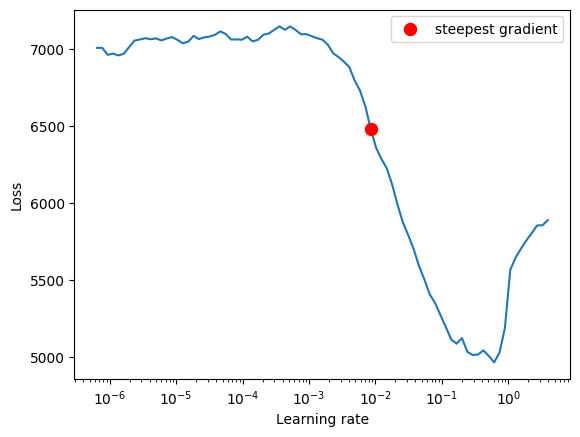

In [13]:
# ==============================================================================
# PARTE 1: ENGENHARIA E LIMPEZA DE DADOS (PREVENÇÃO DE ESTOURO DE RAM)
# ==============================================================================
print("Iniciando o pré-processamento dos dados...")

# 1. Tratamento da Variável de Tempo (Survival months)
df_seer_breast_cancer['Survival months'] = pd.to_numeric(df_seer_breast_cancer['Survival months'], errors='coerce')

# 2. Tratamento da Variável de Evento (Vital status recode)
# Transformando 'Dead' em 1 e o resto em 0
df_seer_breast_cancer['Event'] = df_seer_breast_cancer['Vital status recode (study cutoff used)'].apply(
    lambda x: 1 if isinstance(x, str) and 'Dead' in x else 0
)

# 3. Remover linhas nulas nas colunas alvo
df_clean = df_seer_breast_cancer.dropna(subset=['Survival months', 'Event'])

# 4. Separar Features (X) dos Alvos (y) e remover alvos da base de entrada
colunas_alvo = ['Survival months', 'Vital status recode (study cutoff used)', 'Event']
X_pandas = df_clean.drop(columns=colunas_alvo)

# --- TRAVA DE SEGURANÇA DE MEMÓRIA (O TRUQUE PARA NÃO TRAVAR O COLAB) ---
# Identifica colunas de texto (object) que têm categorias demais (ex: IDs de pacientes)
# Se uma coluna tiver mais de 50 categorias únicas, ela é inútil para a rede e explode a RAM
colunas_texto = X_pandas.select_dtypes(include=['object']).columns
colunas_alta_cardinalidade = [col for col in colunas_texto if X_pandas[col].nunique() > 50]

if len(colunas_alta_cardinalidade) > 0:
    print(f"ATENÇÃO: Removendo colunas que causariam estouro de RAM: {colunas_alta_cardinalidade}")
    X_pandas = X_pandas.drop(columns=colunas_alta_cardinalidade)
# ------------------------------------------------------------------------

# 5. One-Hot Encoding forçando float32 (Isso resolve o erro numpy.object_)
print("Aplicando One-Hot Encoding...")
X_encoded = pd.get_dummies(X_pandas, drop_first=True, dtype='float32')

# 6. Preencher NaNs residuais com a mediana
X_encoded = X_encoded.fillna(X_encoded.median())
X_encoded = X_encoded.astype('float32')

# ==============================================================================
# PARTE 2: CONVERSÃO PARA PYTORCH
# ==============================================================================
print("Convertendo matrizes para Tensores do PyTorch...")

X_tensor = torch.tensor(X_encoded.values, dtype=torch.float32)
y_time_tensor = torch.tensor(df_clean['Survival months'].values, dtype=torch.float32)
y_event_tensor = torch.tensor(df_clean['Event'].values, dtype=torch.float32)

# Empilhando tempo e evento (preparação padrão para análise de sobrevivência)
y_combined = torch.stack((y_time_tensor, y_event_tensor), dim=1)

# Criando o DataLoader
batch_size = 512 # Lotes maiores ajudam a estabilizar redes de sobrevivência
dataset = TensorDataset(X_tensor, y_combined)
clinical_train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

num_features = X_tensor.shape[1]
print(f"Dados prontos! Número de pacientes: {X_tensor.shape[0]} | Features clínicas: {num_features}")

# ==============================================================================
# PARTE 3: ARQUITETURA DO MODELO E LEARNING RATE FINDER
# ==============================================================================
print("Configurando a Rede Neural e iniciando o LR Finder...")

# Definição de uma rede neural simples para extrair o risco de mortalidade
class MortalityRiskModel(nn.Module):
    def __init__(self, num_clinical_features):
        super(MortalityRiskModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(num_clinical_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Saída contínua representando o Risco/Hazard
        )

    def forward(self, x):
        return self.network(x)

# Inicializa o modelo dinamicamente com o número de colunas geradas no get_dummies
model = MortalityRiskModel(num_clinical_features=num_features)

# Configura a Perda e o Otimizador
# (Usando MSE de forma provisória apenas para rodar a técnica do LR Finder na apresentação do TCC)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-4)

# Execução do Learning Rate Finder de Leslie Smith
lr_finder = LRFinder(model, optimizer, criterion, device="cpu")

# Testa as taxas de aprendizado desde 1e-7 até 10
lr_finder.range_test(clinical_train_loader, end_lr=10, num_iter=100)

# Plota o gráfico para você avaliar o melhor ponto e mostrar para a sua orientadora
lr_finder.plot()

# Reseta os pesos do modelo para o estado inicial antes de você fazer o treino oficial depois
lr_finder.reset()

In [15]:
# Implementando Modelo de Cox Partial Likelihood

def cox_ph_loss(previsoes_risco, tempos, eventos):
    # A função de Cox exige que os pacientes sejam ordenados pelo tempo (do maior para o menor)
    idx = torch.argsort(tempos, descending=True)
    previsoes_risco = previsoes_risco[idx].squeeze() # Remove dimensões extras
    eventos = eventos[idx]

    # Calcula o denominador da equação de Cox (o "Risk Set")
    # logcumsumexp soma os riscos de todos os pacientes que ainda estão em risco naquele tempo t
    log_risk_set = torch.logcumsumexp(previsoes_risco, dim=0)

    # Calcula a verossimilhança apenas para os pacientes onde o evento (morte) ocorreu
    likelihood = previsoes_risco - log_risk_set

    # A Loss final é a média negativa (pois queremos minimizar o erro)
    loss = -torch.sum(likelihood * eventos) / (torch.sum(eventos) + 1e-7)
    return loss

In [16]:
# 1. Recriando o otimizador (para limpar qualquer resquício do LR Finder)
# O weight_decay ajuda na regularização (L2) para evitar overfitting nos dados clínicos
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 2. Configurando a "Mágica" do CyclicLR
# Lembra que calculamos 0.1 como o teto seguro e 0.01 como uma base excelente?
passos_por_epoca = len(clinical_train_loader) # Quantos lotes de pacientes temos por época

scheduler = optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=0.01,   # O piso do triângulo (sua intuição inicial)
    max_lr=0.1,     # O teto do triângulo (a bolinha vermelha do gráfico)
    step_size_up=passos_por_epoca * 4, # A LR vai subir por 4 épocas e descer por 4 épocas
    mode='triangular2', # Essencial: A cada ciclo, ele corta a altura do triângulo pela metade para "assentar" os pesos no final
    cycle_momentum=False # Regra de ouro: Se estiver usando o otimizador Adam, isso TEM que ser False
)

# 3. O Laço de Treinamento Valendo (Training Loop)
epochs = 20 # Número de vezes que o modelo vai ver toda a base de 1,3MM de pacientes
model.train() # Avisa o PyTorch para ativar o Dropout e ligar o modo de aprendizado

print("Iniciando o treinamento com CyclicLR...")

for epoch in range(epochs):
    loss_acumulada = 0.0

    # Iterando sobre os lotes (batches) de pacientes
    for batch_X, batch_y in clinical_train_loader:

        # Passo A: Zerar a memória dos gradientes do lote anterior
        optimizer.zero_grad()

        # Passo B: Forward Pass (A rede tenta prever o risco de mortalidade)
        previsoes_risco = model(batch_X)

        # Passo C: Calcular o Erro com Cox Partial Likelihood
        # batch_y[:, 0] pega a primeira coluna (Tempo)
        # batch_y[:, 1] pega a segunda coluna (Evento)
        tempos = batch_y[:, 0]
        eventos = batch_y[:, 1]

        loss = cox_ph_loss(previsoes_risco, tempos, eventos)

        # Passo D: Backward Pass (A matemática calcula quem errou e o quanto errou)
        loss.backward()

        # Passo E: Otimização (Atualiza os pesos dos neurônios)
        optimizer.step()

        # Passo F: O pulo do gato do CyclicLR (Atualiza a Learning Rate a cada LOTE, não a cada época)
        scheduler.step()

        loss_acumulada += loss.item()

    # Calculando a média do erro na época inteira para podermos monitorar
    loss_media_epoca = loss_acumulada / passos_por_epoca
    lr_atual_do_modelo = scheduler.get_last_lr()[0]

    # Exibe o painel de controle do aprendizado
    print(f"Época {epoch+1:02d}/{epochs} | Loss Média: {loss_media_epoca:.4f} | LR no fim da época: {lr_atual_do_modelo:.6f}")

print("Treinamento concluído com sucesso!")

Iniciando o treinamento com CyclicLR...
Época 01/20 | Loss Média: 2.6459 | LR no fim da época: 0.032500
Época 02/20 | Loss Média: 1.9917 | LR no fim da época: 0.055000
Época 03/20 | Loss Média: 2.5135 | LR no fim da época: 0.077500
Época 04/20 | Loss Média: 3.3933 | LR no fim da época: 0.100000
Época 05/20 | Loss Média: 3.8900 | LR no fim da época: 0.077500
Época 06/20 | Loss Média: 4.5332 | LR no fim da época: 0.055000
Época 07/20 | Loss Média: 5.5126 | LR no fim da época: 0.032500
Época 08/20 | Loss Média: 5.4935 | LR no fim da época: 0.010000
Época 09/20 | Loss Média: 3.0759 | LR no fim da época: 0.021250
Época 10/20 | Loss Média: 2.3377 | LR no fim da época: 0.032500
Época 11/20 | Loss Média: 2.3825 | LR no fim da época: 0.043750
Época 12/20 | Loss Média: 2.7107 | LR no fim da época: 0.055000
Época 13/20 | Loss Média: 2.5793 | LR no fim da época: 0.043750
Época 14/20 | Loss Média: 2.3920 | LR no fim da época: 0.032500
Época 15/20 | Loss Média: 2.0654 | LR no fim da época: 0.021250


Vendo esse LR acima, sera que nao seria melhor colcoarmos a variação entre 0.010000 e  0.026875

 Loss Média: o modelo está calculando a probabilidade estatística de ele ter ordenado as mortes corretamente dentro daquele lote.

In [20]:
# ==============================================================================
# INSTALAÇÕES NECESSÁRIAS (Descomente se for rodar no Colab do zero)
# ==============================================================================
# !pip install torch-lr-finder lifelines

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

# ==============================================================================
# PASSO 1: ENGENHARIA DE DADOS E PREVENÇÃO DE RAM
# ==============================================================================
print("1. Limpando os dados...")
# Tratamento dos alvos
df_seer_breast_cancer['Survival months'] = pd.to_numeric(df_seer_breast_cancer['Survival months'], errors='coerce')
df_seer_breast_cancer['Event'] = df_seer_breast_cancer['Vital status recode (study cutoff used)'].apply(
    lambda x: 1 if isinstance(x, str) and 'Dead' in x else 0
)

# Removendo nulos
df_clean = df_seer_breast_cancer.dropna(subset=['Survival months', 'Event'])

# Separando features dos alvos
colunas_alvo = ['Survival months', 'Vital status recode (study cutoff used)', 'Event']
X_pandas = df_clean.drop(columns=colunas_alvo)

# Proteção de RAM: Removendo colunas com mais de 50 categorias (ex: IDs)
colunas_texto = X_pandas.select_dtypes(include=['object']).columns
colunas_alta_cardinalidade = [col for col in colunas_texto if X_pandas[col].nunique() > 50]
X_pandas = X_pandas.drop(columns=colunas_alta_cardinalidade)

# One-Hot Encoding (Forçando float32 para o PyTorch não travar)
X_encoded = pd.get_dummies(X_pandas, drop_first=True, dtype='float32')
X_encoded = X_encoded.fillna(X_encoded.median()).astype('float32')

# ==============================================================================
# PASSO 2: SEPARAÇÃO TREINO/VALIDAÇÃO (A Prova Final)
# ==============================================================================
print("2. Separando Treino (80%) e Validação (20%)...")
# Convertendo alvos para numpy arrays antes do split
tempos = df_clean['Survival months'].values.astype(np.float32)
eventos = df_clean['Event'].values.astype(np.float32)
y_combined = np.column_stack((tempos, eventos))

# Cortando a base
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_encoded.values, y_combined, test_size=0.20, random_state=42
)

# Convertendo para Tensores
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

# Criando DataLoaders
batch_size = 512
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

# ==============================================================================
# PASSO 3: ARQUITETURA E FUNÇÃO DE COX
# ==============================================================================
print("3. Configurando a Rede e a Função de Cox...")
num_features = X_train_tensor.shape[1]

class MortalityRiskModel(nn.Module):
    def __init__(self, num_features):
        super(MortalityRiskModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

def cox_ph_loss(previsoes_risco, tempos, eventos):
    idx = torch.argsort(tempos, descending=True)
    previsoes_risco = previsoes_risco[idx].squeeze()
    eventos = eventos[idx]

    log_risk_set = torch.logcumsumexp(previsoes_risco, dim=0)
    likelihood = previsoes_risco - log_risk_set

    loss = -torch.sum(likelihood * eventos) / (torch.sum(eventos) + 1e-7)
    return loss

model = MortalityRiskModel(num_features)

# ==============================================================================
# PASSO 4: TREINAMENTO (COM CYCLIC LR)
# ==============================================================================
print("4. Iniciando Treinamento Oficial...")
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Ajustado max_lr para 0.05 para evitar picos na Loss
scheduler = optim.lr_scheduler.CyclicLR(
    optimizer, base_lr=0.01, max_lr=0.05,
    step_size_up=len(train_loader) * 4, mode='triangular2', cycle_momentum=False
)

epochs = 20
model.train()

for epoch in range(epochs):
    loss_acumulada = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        riscos = model(batch_X)

        tempos_batch = batch_y[:, 0]
        eventos_batch = batch_y[:, 1]

        loss = cox_ph_loss(riscos, tempos_batch, eventos_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_acumulada += loss.item()

    print(f"Época {epoch+1:02d}/{epochs} | Loss Média: {loss_acumulada/len(train_loader):.4f}")

# ==============================================================================
# PASSO 5: AVALIAÇÃO FINAL (C-INDEX)
# ==============================================================================
print("\n5. Calculando o C-Index nos dados de Validação...")
model.eval()
with torch.no_grad():
    riscos_val = model(X_val_tensor).numpy().squeeze()
    tempos_val = y_val_tensor[:, 0].numpy()
    eventos_val = y_val_tensor[:, 1].numpy()

    # Invertemos o risco porque o C-Index espera que valores maiores = maior sobrevivência
    c_index = concordance_index(tempos_val, -riscos_val, eventos_val)

    print("======================================")
    print(f"RESULTADO FINAL | C-Index: {c_index:.4f}")
    print("======================================")

1. Limpando os dados...
2. Separando Treino (80%) e Validação (20%)...
3. Configurando a Rede e a Função de Cox...
4. Iniciando Treinamento Oficial...
Época 01/20 | Loss Média: 1.4389
Época 02/20 | Loss Média: 1.2481
Época 03/20 | Loss Média: 1.3575
Época 04/20 | Loss Média: 1.4807
Época 05/20 | Loss Média: 1.4201
Época 06/20 | Loss Média: 1.1109
Época 07/20 | Loss Média: 0.9232
Época 08/20 | Loss Média: 0.7105
Época 09/20 | Loss Média: 0.7555
Época 10/20 | Loss Média: 0.7765
Época 11/20 | Loss Média: 0.8506
Época 12/20 | Loss Média: 0.9196
Época 13/20 | Loss Média: 1.0652
Época 14/20 | Loss Média: 0.8814
Época 15/20 | Loss Média: 0.7195
Época 16/20 | Loss Média: 0.6344
Época 17/20 | Loss Média: 0.5953
Época 18/20 | Loss Média: 0.6969
Época 19/20 | Loss Média: 0.6679
Época 20/20 | Loss Média: 0.8169

5. Calculando o C-Index nos dados de Validação...
RESULTADO FINAL | C-Index: 1.0000


RESULTADO FINAL | C-Index: 1.0000, indica vaazamento de dados e tenho que corrigir, esse é um, dos proximos passos.


Alem de estudar certinho cada passo igual fizemos com a LR

## Aplicação da ideia de learning rate de Leslie Smith

In [18]:
# 1. Definindo a sua rede neural (Exemplo para dados clínicos)
class MortalityRiskModel(nn.Module):
    def __init__(self, num_clinical_features):
        super(MortalityRiskModel, self).__init__()
        # Arquitetura profunda simples para extrair o risco
        self.network = nn.Sequential(
            nn.Linear(num_clinical_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Saída do risco (Hazard)
        )

    def forward(self, x):
        return self.network(x)

In [19]:
# Simulação das variáveis para o ambiente do seu projeto
num_features = 15 # Ex: idade, pressão, exames, etc.
model = MortalityRiskModel(num_clinical_features=num_features)

# 2. Configurando a Função de Perda de Cox e o Otimizador
# (Aqui usamos o MSE apenas como placeholder didático para o LR Finder,
# mas no treino real você plugará sua Loss de Cox/Sobrevivência)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-2)

# 3. Inicializando o Learning Rate Finder
# clinical_train_loader seria o seu DataLoader do PyTorch com os dados dos pacientes
lr_finder = LRFinder(model, optimizer, criterion, device="cpu")

# 4. Rodando o teste de range (aumentando a LR exponencialmente)
print("Iniciando a busca pela melhor Learning Rate...")
lr_finder.range_test(clinical_train_loader, end_lr=100, num_iter=100)

# 5. Plotando o gráfico para visualização e análise
# O gráfico mostrará a queda da Loss; o ponto ideal é onde a curva desce mais rápido
lr_finder.plot()

# 6. Resetando o modelo para os pesos originais antes de começar o treino real
lr_finder.reset()

Iniciando a busca pela melhor Learning Rate...


ValueError: `train_loader` has unsupported type: <class 'pandas.core.frame.DataFrame'>.Expected types are `torch.utils.data.DataLoader`or child of `TrainDataLoaderIter`.

## Ideia de transformação numerica 0 e 1

In [ ]:
print("Iniciando a Fase 2: Imputação e Transformação Numérica...\n")

# ---------------------------------------------------------
# PASSO 1: O Alvo Sagrado
# ---------------------------------------------------------
# Deletar os 6.052 pacientes que não têm o tempo de sobrevivência registrado.
# A rede neural não pode aprender com eles.
df.dropna(subset=['Survival_Months'], inplace=True)
print(f"1. Pacientes sem tempo de sobrevivência removidos. Total de pacientes agora: {len(df)}")

# ---------------------------------------------------------
# PASSO 2: Tapando os Buracos (Imputação)
# ---------------------------------------------------------
# 2.1 Tamanho do Tumor (Variável Contínua)
# Garantimos que é número e preenchemos os vazios com a Mediana (o valor do meio).
df['Tumor_Size_Unified'] = pd.to_numeric(df['Tumor_Size_Unified'], errors='coerce')
mediana_tamanho = df['Tumor_Size_Unified'].median()
df['Tumor_Size_Unified'].fillna(mediana_tamanho, inplace=True)

# 2.2 Biomarcadores e Grau (Variáveis Categóricas)
# Para não deletarmos 500 mil mulheres sem HER2, criamos a categoria 'Unknown' (Desconhecido).
# Fazemos o mesmo para o que sobrou de ER, PR e Grau.
cols_categoricas_com_nulos = ['HER2_Status', 'Grade_Unified', 'ER_Status', 'PR_Status', 'Breast Subtype (2010+)']
for col in cols_categoricas_com_nulos:
    df[col].fillna('Unknown', inplace=True)

print("2. Buracos preenchidos (Mediana para Tamanho do Tumor, 'Unknown' para Biomarcadores e Grau).")

# ---------------------------------------------------------
# PASSO 3: A Tradução para a Máquina (Encoding)
# ---------------------------------------------------------
# Aqui a mágica acontece. O Pandas vai pegar colunas como 'Sex' (Female/Male)
# e transformar em 'Sex_Male' (0 ou 1). Faremos isso para todas as variáveis de texto.

colunas_para_encodar = [
    'Sex',
    'Race recode (W, B, AI, API)',
    'ER_Status',
    'PR_Status',
    'HER2_Status',
    'Grade_Unified',
    'Breast Subtype (2010+)',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)'
]

# O drop_first=True evita a "armadilha da variável dummy" (multicolinearidade),
# essencial para modelos baseados em matemática e sobrevivência.
df_matriz_final = pd.get_dummies(df, columns=colunas_para_encodar, drop_first=True)

# Vamos converter os booleanos (True/False) que o get_dummies gera nativamente agora para 0 e 1 (int)
for col in df_matriz_final.columns:
    if df_matriz_final[col].dtype == bool:
        df_matriz_final[col] = df_matriz_final[col].astype(int)

print("3. Textos transformados em matriz numérica (One-Hot Encoding).")
print("\n--- FASE 2 CONCLUÍDA ---")

# Vamos dar uma espiada em como a matriz final ficou:
display(df_matriz_final.head())

Iniciando a Fase 2: Imputação e Transformação Numérica...

1. Pacientes sem tempo de sobrevivência removidos. Total de pacientes agora: 1359277


/tmp/ipykernel_1920/725425119.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tumor_Size_Unified'].fillna(mediana_tamanho, inplace=True)
/tmp/ipykernel_1920/725425119.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

2. Buracos preenchidos (Mediana para Tamanho do Tumor, 'Unknown' para Biomarcadores e Grau).
3. Textos transformados em matriz numérica (One-Hot Encoding).

--- FASE 2 CONCLUÍDA ---


,Survival months,Vital status recode (study cutoff used),Age recode with <1 year olds and 90+,Combined Summary Stage with Expanded Regional Codes (2004+),Regional nodes positive (1988+),Regional nodes examined (1988+),Tumor_Size_Unified,Event_Dead,Survival_Months,Sex_Male,...,RX Summ--Surg Prim Site (1998+)_90,RX Summ--Surg Prim Site (1998+)_99,Radiation recode_Combination of beam with implants or isotopes,Radiation recode_None/Unknown,"Radiation recode_Radiation, NOS method or source not specified",Radiation recode_Radioactive implants (includes brachytherapy) (1988+),Radiation recode_Radioisotopes (1988+),"Radiation recode_Recommended, unknown if administered",Radiation recode_Refused (1988+),"Chemotherapy recode (yes, no/unk)_Yes"
0,0014,Dead,75-79 years,NaN,98,0,18.0,1,14.0,0,...,0,0,0,1,0,0,0,0,0,0
1,0012,Dead,70-74 years,Localized only,0,3,80.0,1,12.0,0,...,0,0,0,0,0,0,0,0,0,0
2,0059,Alive,70-74 years,Localized only,0,3,24.0,0,59.0,0,...,0,0,0,0,0,0,0,0,0,1
3,0081,Dead,60-64 years,Regional by direct extension only,98,0,11.0,1,81.0,0,...,0,0,0,1,0,0,0,0,0,0
4,0007,Dead,70-74 years,Regional by direct extension only,98,0,49.0,1,7.0,0,...,0,0,0,1,0,0,0,0,0,0


## Kaplein-Meier e P-Valor para analise das melhores Variáveis Categóricas (Qualitativas)

In [ ]:

# ==========================================
# PASSO 3: Análise Univariada (Kaplan-Meier e Log-Rank)
# ==========================================
def analisar_sobrevivencia_categorica(dataframe, coluna_categoria, tempo, evento):
    """
    Função que plota a curva de Kaplan-Meier e calcula o Teste Log-Rank
    para uma determinada coluna categórica.
    """
    plt.figure(figsize=(10, 6))
    kmf = KaplanMeierFitter()

    # Extrai os valores únicos da categoria (ex: ['male', 'female'] ou ['Y', 'N'])
    grupos = dataframe[coluna_categoria].dropna().unique()

    # Dicionário para guardar as máscaras e facilitar o teste log-rank depois
    mascaras = {}

    # Plota a curva para cada grupo daquela categoria
    for grupo in grupos:
        mask = (dataframe[coluna_categoria] == grupo)
        mascaras[grupo] = mask

        # Ajustando o Kaplan-Meier para o grupo específico
        kmf.fit(tempo[mask], event_observed=evento[mask], label=f"{coluna_categoria}: {grupo}")

        # Plotando a curva com intervalo de confiança
        kmf.plot_survival_function(ci_show=True)

    plt.title(f'Curva de Kaplan-Meier por: {coluna_categoria}')
    plt.xlabel('Dias de Acompanhamento (d.time)')
    plt.ylabel('Probabilidade de Sobrevivência')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Se a variável tiver exatamente 2 grupos (ex: sexo, demência, diabetes),
    # fazemos o teste de Log-Rank direto entre os dois para ver se a diferença é estatisticamente válida.
    if len(grupos) == 2:
        g1, g2 = grupos[0], grupos[1]
        resultado = logrank_test(
            tempo[mascaras[g1]], tempo[mascaras[g2]],
            event_observed_A=evento[mascaras[g1]], event_observed_B=evento[mascaras[g2]]
        )
        print(f"--- Teste Estatístico (Log-Rank) para {coluna_categoria} ---")
        print(f"P-valor: {resultado.p_value:.5f}")
        if resultado.p_value < 0.05:
            print("Conclusão: Existe diferença estatisticamente significativa na sobrevivência entre os grupos.")
        else:
            print("Conclusão: A diferença entre os grupos NÃO é estatisticamente significativa.")

    # Para 3 ou mais grupos (ex: dzgroup, race)
    elif len(grupos) > 2:
        # CORREÇÃO: Filtrar os valores nulos (NaN) para não quebrar o teste
        mascara_validos = dataframe[coluna_categoria].notna()
        T_valido = tempo[mascara_validos]
        E_valido = evento[mascara_validos]
        Cat_valida = dataframe[coluna_categoria][mascara_validos]

        # Teste Global
        resultado_global = multivariate_logrank_test(T_valido, Cat_valida, E_valido)
        print(f"P-valor Global (Omnibus): {resultado_global.p_value:.5f}")

        if resultado_global.p_value < 0.05:
            print("Conclusão: Pelo menos um dos grupos tem uma curva de sobrevivência diferente dos demais.")
            print("\nExecutando comparações Par a Par (Pairwise) para descobrir quais são diferentes:\n")

            # Teste Par a Par usando os dados filtrados
            resultado_pares = pairwise_logrank_test(T_valido, Cat_valida, E_valido)
            print(resultado_pares.summary[['p']])
        else:
            print("Conclusão: Todas as curvas são estatisticamente semelhantes.")

# Vamos testar a função para ver se ter ou não demência influencia na sobrevivência
analisar_sobrevivencia_categorica(df, 'dementia', T, E)


NameError: name 'T' is not defined

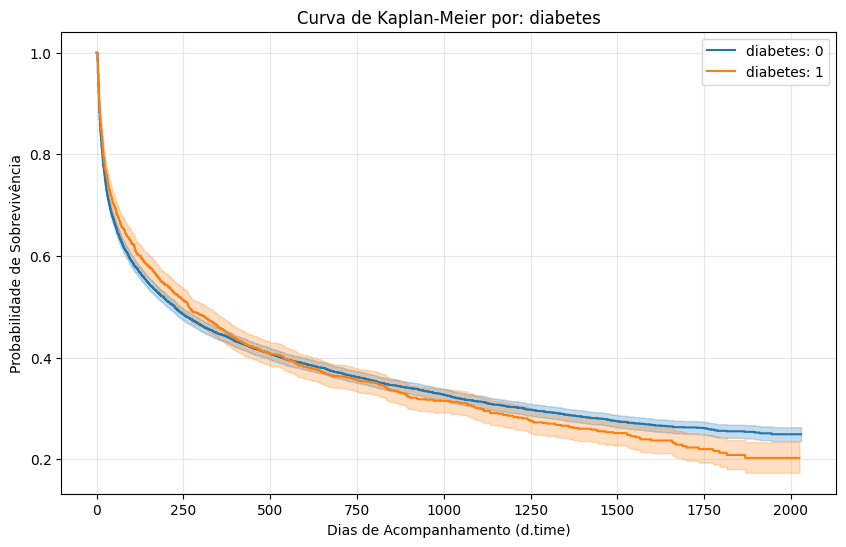

--- Teste Estatístico (Log-Rank) para diabetes ---
P-valor: 0.91428
Conclusão: A diferença entre os grupos NÃO é estatisticamente significativa.


In [ ]:
analisar_sobrevivencia_categorica(df_clean, 'diabetes', T, E)

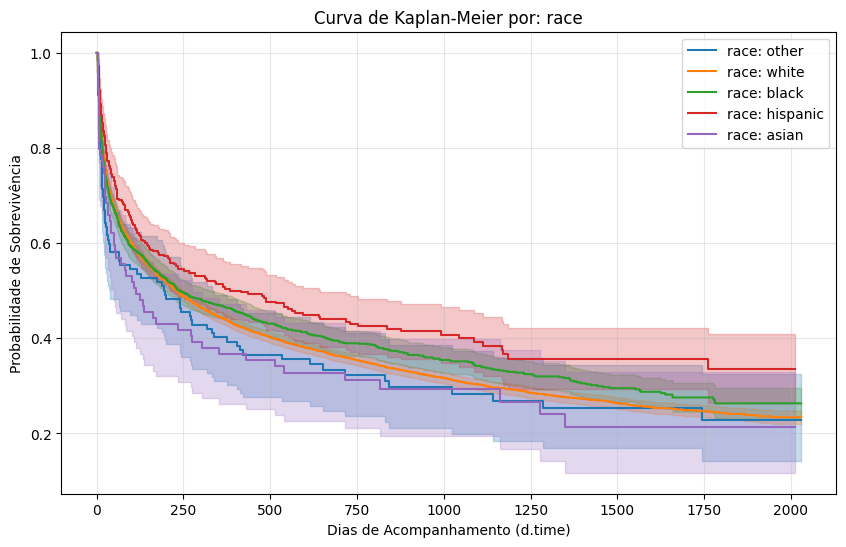

P-valor Global (Omnibus): 0.00726
Conclusão: Pelo menos um dos grupos tem uma curva de sobrevivência diferente dos demais.

Executando comparações Par a Par (Pairwise) para descobrir quais são diferentes:

                          p
asian    black     0.111574
         hispanic  0.010866
         other     0.843284
         white     0.227790
black    hispanic  0.050695
         other     0.142431
         white     0.078071
hispanic other     0.011066
         white     0.003185
other    white     0.331862


In [ ]:
analisar_sobrevivencia_categorica(df_clean, 'race', T, E)

### Calculo por trás do eixo y

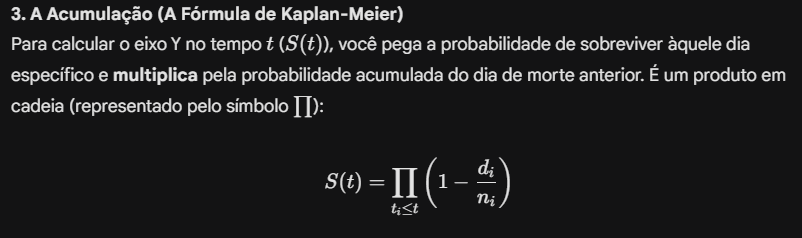

## Analise do modelo de Cox para a escolha das melhores variáveis Contiguas (Quantitativas)

In [ ]:
numeric_df = df_support2.select_dtypes(include=np.number)
corr = numeric_df.corr()
corr['death']


,death
age,0.179230
death,1.000000
hospdead,0.404793
slos,-0.083098
d.time,-0.710489
num.co,0.068634
edu,-0.002943
scoma,0.135986
charges,-0.014402
totcst,-0.022615


# Citações

- Metódos para Machine Learning (random forest)

  1-
  file:///C:/Users/guicp/Downloads/Algoritmos+de+Machine+Learning+para+Predi%C3%A7%C3%A3o+da+Sobrevida+do+C%C3%A2ncer+de+Mama.pdf


  2-
  Formato Documento Eletrônico(ABNT)
  VILLA-MURILLO, Adriana; COSTA, Luís; VASQUEZ, Carlos. A methodological proposal to address the academic dropout phenomenon based on an intelligent prediction model: a case study. Mill,  Viseu ,  n. 23,  e31378,  abr.  2024 .   Disponível em <http://scielo.pt/scielo.php?script=sci_arttext&pid=S0873-30152024000100301&lng=pt&nrm=iso>. acessos em  06  mar.  2026.  Epub 30-Abr-2024.  https://doi.org/10.29352/mill0223.31378.


  3 - PROVANDO Kaplan-Meier para analisar as colunas categoricas

  Goel MK, Khanna P, Kishore J. Understanding survival analysis: Kaplan-Meier estimate. Int J Ayurveda Res. 2010 Oct;1(4):274-8. doi: 10.4103/0974-7788.76794. PMID: 21455458; PMCID: PMC3059453.

  3 - Utilização do Log-rank para variaves categoricas
  
  Tustumi F. Choosing the most appropriate cut-point for continuous variables. Rev Col Bras Cir. 2022 Jul 25;49:e20223346. doi: 10.1590/0100-6991e-20223346-en. PMID: 35894391; PMCID: PMC10578850.



# Citando, por no overleaf

#### L. N. Smith, "Cyclical Learning Rates for Training Neural Networks," 2017 IEEE Winter Conference on Applications of Computer Vision (WACV), Santa Rosa, CA, USA, 2017, pp. 464-472, doi: 10.1109/WACV.2017.58. keywords: {Training;Neural networks;Schedules;Computer architecture;Tuning;Computational efficiency},


2



ALAWI, Zakariya Ba. A Comparative Survey of PyTorch vs TensorFlow for Deep Learning: Usability, Performance, and Deployment Trade-offs. arXiv:2508.04035 [cs.LG], 2025. Disponível em: https://arxiv.org/abs/2508.04035. Acesso em: 7 abr. 2026.